In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Import the Required Libraries

In [1]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor, Compose, Resize
from torch.utils.data import random_split, DataLoader
from torchvision.utils import make_grid
from sklearn.metrics import classification_report, confusion_matrix

%matplotlib inline
plt.style.use('ggplot')

### Download and Unzip the Dataset

In [2]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d rajumavinmar/finger-print-based-blood-group-dataset

Dataset URL: https://www.kaggle.com/datasets/rajumavinmar/finger-print-based-blood-group-dataset
License(s): unknown
  0% 0.00/58.1M [00:00<?, ?B/s]
100% 58.1M/58.1M [00:00<00:00, 1.73GB/s]


In [4]:
zip_path = '/content/finger-print-based-blood-group-dataset.zip'
extract_path = '/content'

if os.path.exists(zip_path):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete.")
else:
    print(f"File not found: {zip_path}. Please upload the dataset.")

data_dir = os.path.join(extract_path, "dataset_blood_group")
print(f"Data directory: {data_dir}")

Extracting /content/finger-print-based-blood-group-dataset.zip...
Extraction complete.
Data directory: /content/dataset_blood_group


### Load and Transform Data

In [5]:
# Define transforms
transform = Compose([
    Resize((128, 128)),
    ToTensor()
])

# Load dataset
try:
    dataset = ImageFolder(data_dir, transform=transform)
    print(f"Total images: {len(dataset)}")
    print(f"Classes: {dataset.classes}")
except FileNotFoundError:
    print("Dataset folder not found. Check the path in Cell 2.")

Total images: 6000
Classes: ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']


### Split Dataset (Train/Val/Test)

In [6]:
random_seed = 42
torch.manual_seed(random_seed)

val_size = 1000
test_size = 1000
train_size = len(dataset) - val_size - test_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

print(f"Training Size: {len(train_ds)}")
print(f"Validation Size: {len(val_ds)}")
print(f"Testing Size: {len(test_ds)}")

Training Size: 4000
Validation Size: 1000
Testing Size: 1000


### Create Data Loaders and Visualize Batch

In [9]:
batch_size = 32

# Create DataLoaders
train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size*2, num_workers=2, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size*2, num_workers=2, pin_memory=True)

### Define Model Architecture

In [10]:
def conv_block(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
              nn.BatchNorm2d(out_channels),
              nn.ReLU(inplace=True)]
    if pool:
        layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)

class ResNet9(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.conv1 = conv_block(in_channels, 64)
        self.conv2 = conv_block(64, 128, pool=True)
        self.res1 = nn.Sequential(conv_block(128, 128), conv_block(128, 128))

        self.conv3 = conv_block(128, 256, pool=True)
        self.conv4 = conv_block(256, 512, pool=True)
        self.res2 = nn.Sequential(conv_block(512, 512), conv_block(512, 512))

        self.classifier = nn.Sequential(nn.AdaptiveMaxPool2d(1),
                                        nn.Flatten(),
                                        nn.Dropout(0.2),
                                        nn.Linear(512, num_classes))

    def forward(self, xb):
        out = self.conv1(xb)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.res2(out) + out
        out = self.classifier(out)
        return out

### Device Setup & Helper Class

In [12]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

device = get_default_device()

train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
test_dl = DeviceDataLoader(test_dl, device)

### Training Utilities

In [17]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = []
    for batch in val_loader:
        images, labels = batch
        out = model(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        outputs.append({'val_loss': loss.detach(), 'val_acc': acc})

    batch_losses = [x['val_loss'] for x in outputs]
    epoch_loss = torch.stack(batch_losses).mean()
    batch_accs = [x['val_acc'] for x in outputs]
    epoch_acc = torch.stack(batch_accs).mean()
    return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

def fit_one_cycle(epochs, max_lr, model, train_loader, val_loader,
                  weight_decay=0, grad_clip=None, opt_func=torch.optim.SGD):
    torch.cuda.empty_cache()
    history = []

    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs,
                                                steps_per_epoch=len(train_loader))

    for epoch in range(epochs):
        model.train()
        train_losses = []
        train_accs = []
        lrs = []

        for batch in train_loader:
            images, labels = batch
            out = model(images)
            loss = F.cross_entropy(out, labels)
            acc = accuracy(out, labels)

            train_losses.append(loss)
            train_accs.append(acc)

            loss.backward()

            if grad_clip:
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)

            optimizer.step()
            optimizer.zero_grad()

            lrs.append(optimizer.param_groups[0]['lr'])
            sched.step()

        # Validation Phase
        result = evaluate(model, val_loader)

        # Store average train loss and accuracy
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['train_acc'] = torch.stack(train_accs).mean().item()
        result['lrs'] = lrs
        result['epoch'] = epoch
        history.append(result)

        print("Epoch [{}], train_loss: {:.4f}, train_acc: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['train_loss'], result['train_acc'], result['val_loss'], result['val_acc']))

    return history

### Initialize Model and Train

In [20]:
model = to_device(ResNet9(3, 8), device)

epochs = 20
max_lr = 0.01
grad_clip = 0.1
weight_decay = 1e-4
opt_func = torch.optim.Adam

history = fit_one_cycle(epochs, max_lr, model, train_dl, val_dl,
                             grad_clip=grad_clip,
                             weight_decay=weight_decay,
                             opt_func=opt_func)

Epoch [0], train_loss: 1.4977, train_acc: 0.4750, val_loss: 0.9190, val_acc: 0.6357
Epoch [1], train_loss: 1.0107, train_acc: 0.6403, val_loss: 4.2940, val_acc: 0.3416
Epoch [2], train_loss: 1.1708, train_acc: 0.6242, val_loss: 1.9433, val_acc: 0.5535
Epoch [3], train_loss: 1.2094, train_acc: 0.6428, val_loss: 3.6545, val_acc: 0.4672
Epoch [4], train_loss: 1.3913, train_acc: 0.6373, val_loss: 1.6302, val_acc: 0.5883
Epoch [5], train_loss: 0.9740, train_acc: 0.7100, val_loss: 2.3744, val_acc: 0.5748
Epoch [6], train_loss: 0.7849, train_acc: 0.7455, val_loss: 1.1862, val_acc: 0.6625
Epoch [7], train_loss: 0.6579, train_acc: 0.7682, val_loss: 0.6444, val_acc: 0.7520
Epoch [8], train_loss: 0.5979, train_acc: 0.7837, val_loss: 1.3127, val_acc: 0.6451
Epoch [9], train_loss: 0.5006, train_acc: 0.8155, val_loss: 0.8657, val_acc: 0.7033
Epoch [10], train_loss: 0.4726, train_acc: 0.8207, val_loss: 0.4605, val_acc: 0.8193
Epoch [11], train_loss: 0.4089, train_acc: 0.8388, val_loss: 0.4004, val_ac

In [21]:
model_save_path = 'pytorch.pth'
torch.save(model.state_dict(), model_save_path)

print(f"Model saved successfully.")

Model saved successfully.


### Model Evaluation

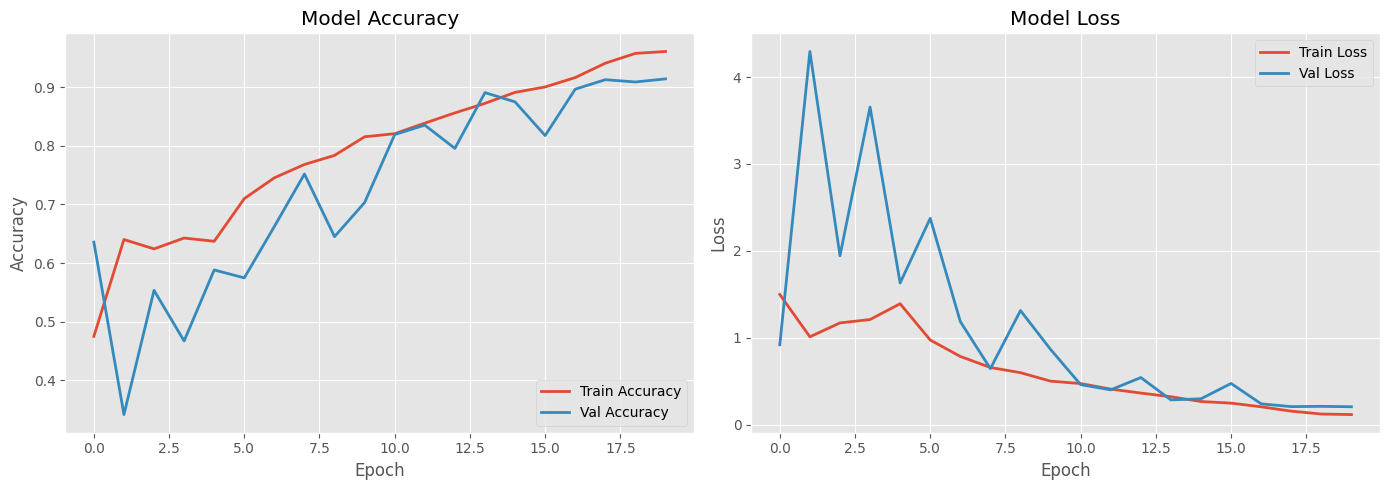

In [22]:
def plot_training_history(history):
    train_acc = [x.get('train_acc') for x in history]
    val_acc = [x['val_acc'] for x in history]
    train_loss = [x.get('train_loss') for x in history]
    val_loss = [x['val_loss'] for x in history]

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy Plot
    axs[0].plot(train_acc, label='Train Accuracy', linewidth=2)
    axs[0].plot(val_acc, label='Val Accuracy', linewidth=2)
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].legend(loc='lower right')
    axs[0].grid(True)

    # Loss Plot
    axs[1].plot(train_loss, label='Train Loss', linewidth=2)
    axs[1].plot(val_loss, label='Val Loss', linewidth=2)
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(loc='upper right')
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [23]:
@torch.no_grad()
def get_all_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    for images, labels in loader:
        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

# Get predictions on test set
y_pred, y_true = get_all_predictions(model, test_dl)
class_names = dataset.classes

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

          A+       0.91      0.94      0.92        95
          A-       0.92      0.93      0.92       158
         AB+       0.94      0.91      0.92       128
         AB-       0.92      0.93      0.92       138
          B+       0.98      0.94      0.96       115
          B-       0.96      0.98      0.97       113
          O+       0.84      0.90      0.87       132
          O-       0.90      0.83      0.87       121

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



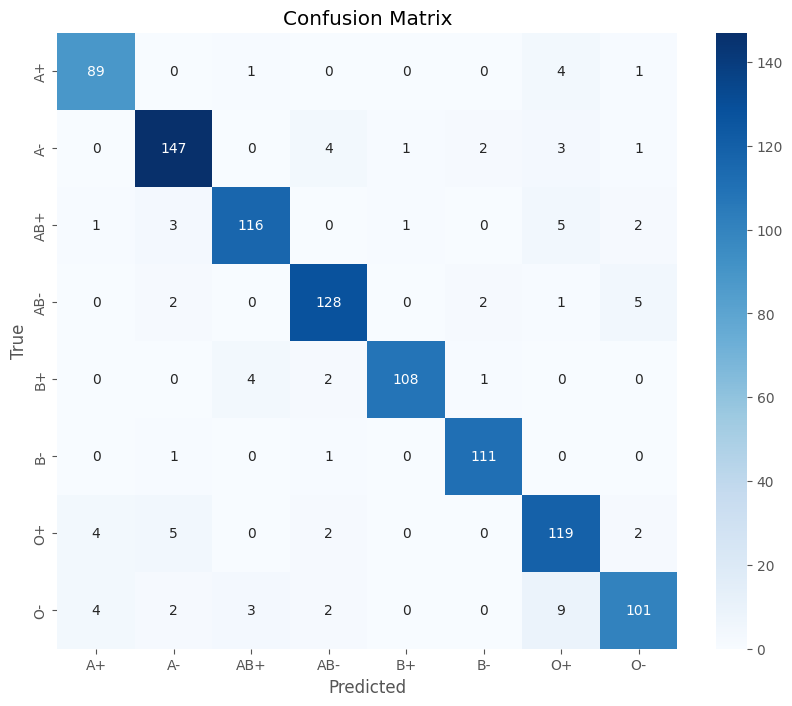

In [24]:
# Confusion Matrix
plt.figure(figsize=(10, 8))
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Model Prediction

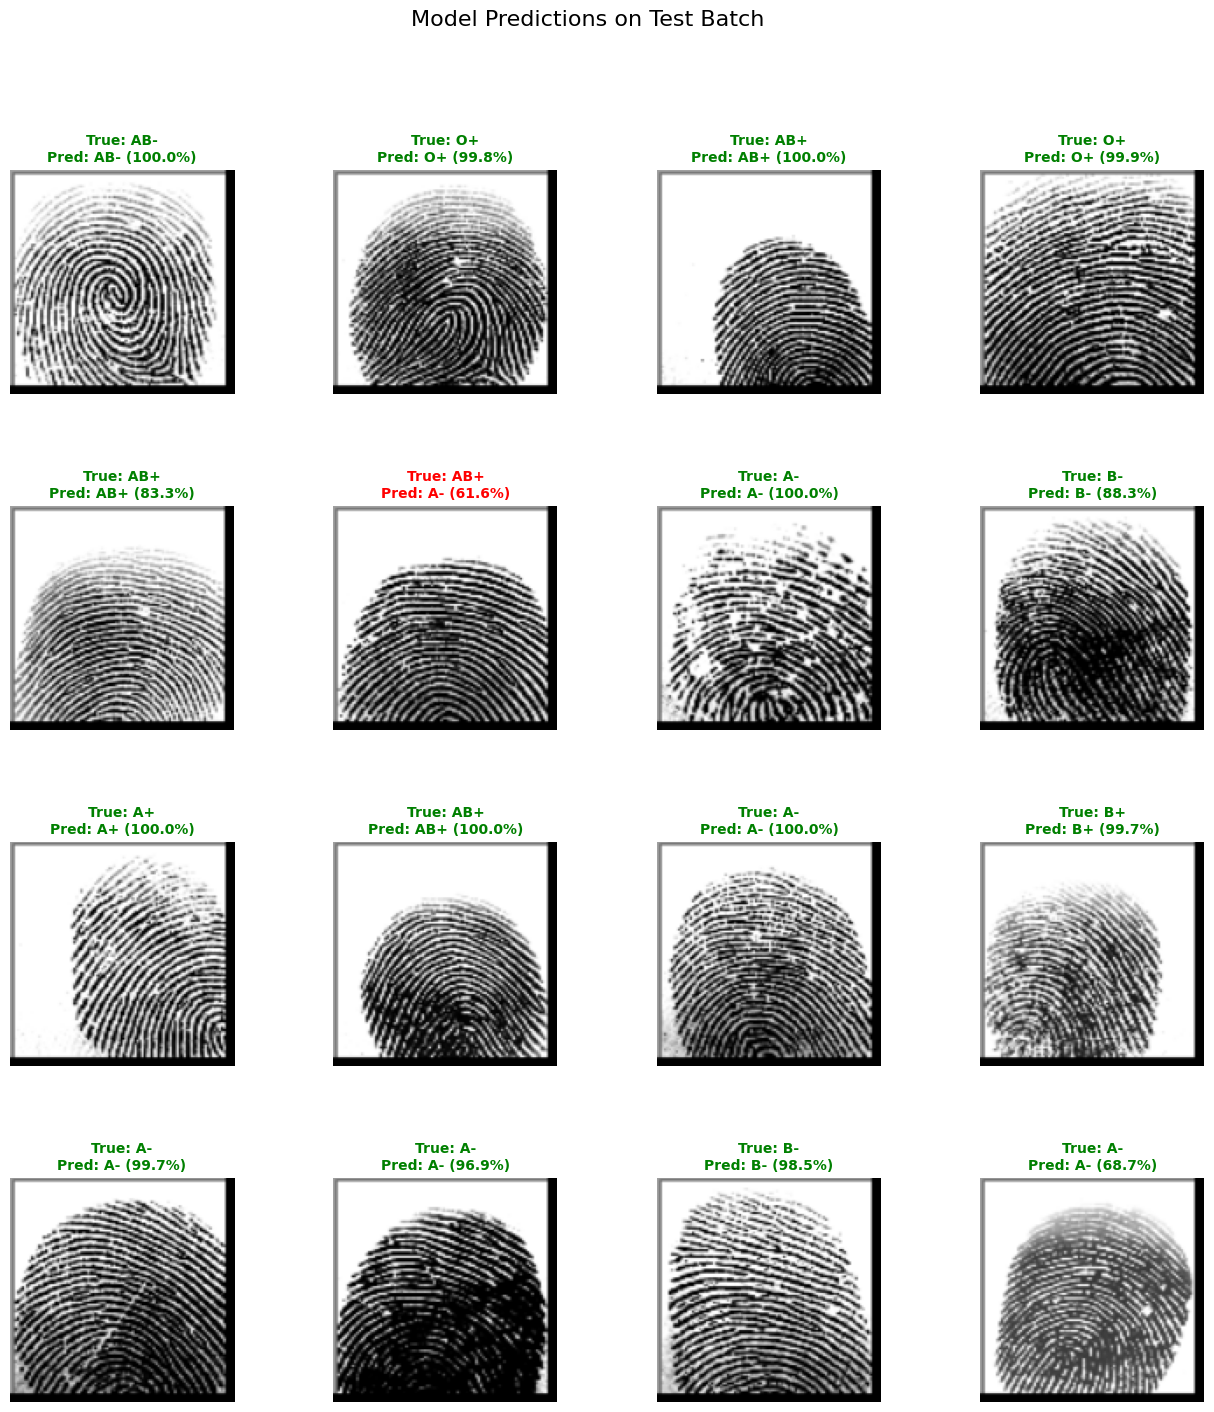

In [29]:
def predict_and_visualize_batch(model, dl, class_names, batch_idx=0):
    for i, (images, labels) in enumerate(dl):
        if i == batch_idx:
            images_dev = to_device(images, device)
            outputs = model(images_dev)
            probs = F.softmax(outputs, dim=1)
            max_probs, preds = torch.max(probs, dim=1)

            images = images.cpu()
            preds = preds.cpu()
            max_probs = max_probs.cpu()
            labels = labels.cpu()
            break

    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    plt.subplots_adjust(hspace=0.5)

    for i, ax in enumerate(axes.flat):
        if i < len(images):
            img = images[i].permute(1, 2, 0)
            ax.imshow(img)

            true_lbl = class_names[labels[i]]
            pred_lbl = class_names[preds[i]]
            conf = max_probs[i] * 100

            color = 'green' if true_lbl == pred_lbl else 'red'
            ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl} ({conf:.1f}%)", color=color, fontsize=10, fontweight='bold')
            ax.axis('off')

    plt.suptitle("Model Predictions on Test Batch", fontsize=16)
    plt.show()

predict_and_visualize_batch(model, test_dl, dataset.classes, batch_idx=3)